# Basic Data Visualizations

# Premodel


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()

weather = pd.read_csv("Refined Datasets/All_Cleaned_Data.csv",index_col=1, encoding='latin1' )
weather.head(10)

,name,humidity,precip,precipcover,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,sunrise,sunset,tempmax c,tempmin c,avgtemp c,feelslikemax c,feelslikemin c,avgfeelsliketemp c,dewpoint c
datetime,,,,,,,,,,,,,,,,,,,,
2005-01-01,Arima,92.8,33.6296,12.50,10.3,70.6,1013.4,87.1,6.4,195.28750,16.87500,23007.0,64462.0,29.0,24.1,25.4,34.6,24.1,26.2,24.1
2005-01-02,Arima,78.9,6.1722,4.17,13.8,40.1,1013.2,64.6,7.8,203.92500,17.66875,23031.0,64495.0,32.0,23.1,26.6,34.2,23.1,27.5,22.1
2005-01-03,Arima,81.5,0.4826,4.17,8.1,62.6,1012.6,54.8,8.4,213.55000,18.44375,23053.0,64527.0,31.8,22.1,25.5,34.0,22.1,26.4,21.8
2005-01-04,Arima,93.2,12.1666,12.50,11.4,67.1,1011.6,83.1,6.8,202.96250,17.59375,23075.0,64560.0,29.2,23.1,24.6,33.7,23.1,25.1,23.3
2005-01-05,Arima,83.2,0.7874,4.17,4.7,50.1,1012.7,77.9,16.8,195.77500,16.91875,23096.0,64593.0,31.3,23.7,25.1,33.4,23.7,25.3,21.8
2005-01-06,Arima,83.2,2.1590,4.17,10.3,67.5,1010.8,92.5,9.8,189.95625,16.42500,23116.0,64625.0,30.2,24.6,26.6,34.7,24.6,27.7,23.3
2005-01-07,Arima,90.5,10.7950,8.33,16.1,73.2,1010.8,95.0,4.4,191.00625,16.45625,23136.0,64658.0,27.1,23.1,24.9,30.4,23.1,25.7,23.2
2005-01-08,Arima,81.3,8.8138,4.17,10.3,78.7,1011.9,90.0,10.0,203.01250,17.55625,23154.0,64690.0,29.2,24.1,26.4,32.7,24.1,28.0,22.7
2005-01-09,Arima,78.5,0.0000,0.00,12.8,82.9,1011.6,81.6,9.5,198.69375,17.16250,23172.0,64722.0,30.1,23.7,27.3,34.2,23.7,29.5,23.1


In [74]:
#Unique locations
print("Unique locations:", weather['name'].nunique())

Unique locations: 16


In [75]:
weather.apply(pd.isnull).sum()  # Check for missing values in the DataFrame, everything should be 0

name                  0
humidity              0
precip                0
precipcover           0
windspeed             0
winddir               0
sealevelpressure      0
cloudcover            0
visibility            0
solarradiation        0
solarenergy           0
sunrise               0
sunset                0
tempmax c             0
tempmin c             0
avgtemp c             0
feelslikemax c        0
feelslikemin c        0
avgfeelsliketemp c    0
dewpoint c            0
dtype: int64

In [76]:
weather.index = pd.to_datetime(weather.index)   # Convert index to datetime if not already
weather.index

DatetimeIndex(['2005-01-01', '2005-01-02', '2005-01-03', '2005-01-04',
               '2005-01-05', '2005-01-06', '2005-01-07', '2005-01-08',
               '2005-01-09', '2005-01-10',
               ...
               '2025-04-18', '2025-04-19', '2025-04-20', '2025-04-21',
               '2025-04-22', '2025-04-23', '2025-04-24', '2025-04-25',
               '2025-04-26', '2025-04-27'],
              dtype='datetime64[ns]', name='datetime', length=120527, freq=None)

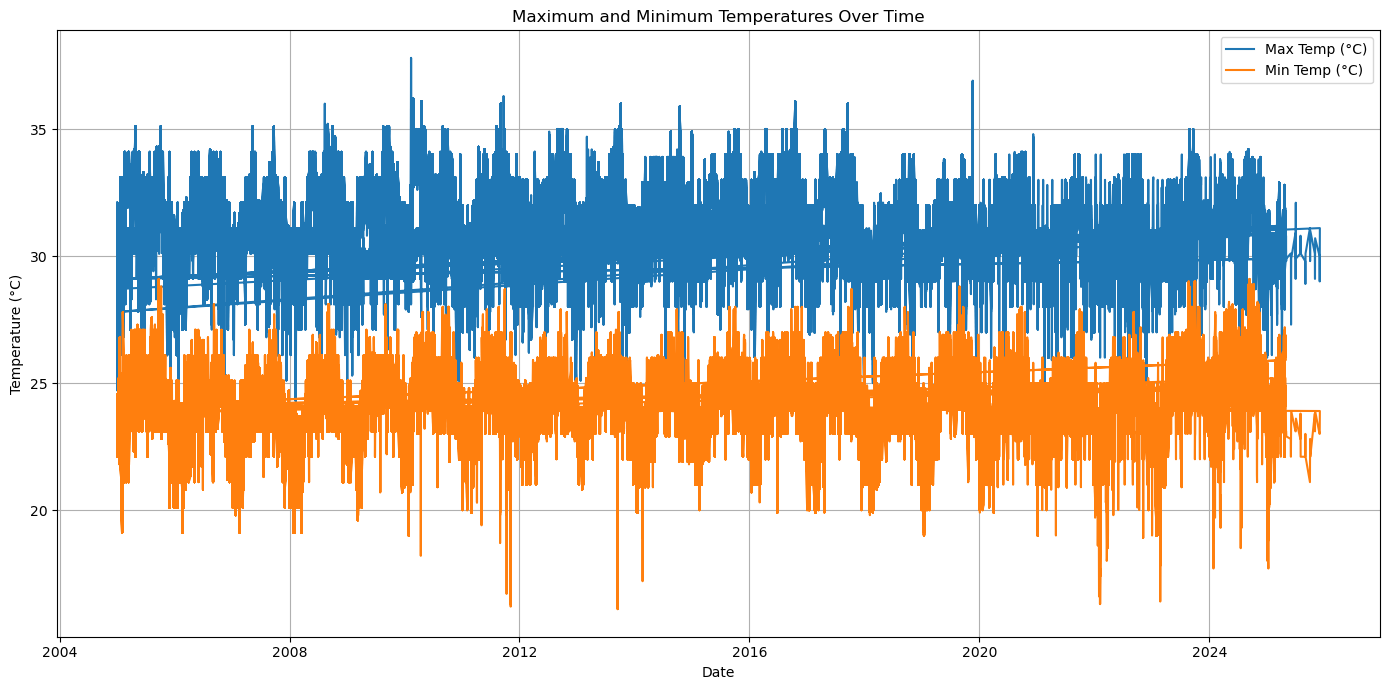

In [77]:
# Plotting the maximum and minimum temperatures
plt.figure(figsize=(14, 7))
plt.plot(weather.index, weather['tempmax c'], color=color_pal[0], label='Max Temp (°C)')
plt.plot(weather.index, weather['tempmin c'], color=color_pal[1], label='Min Temp (°C)')
plt.grid(True)
plt.title("Maximum and Minimum Temperatures Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend(["Max Temp (°C)", "Min Temp (°C)"])

plt.tight_layout()
plt.show()


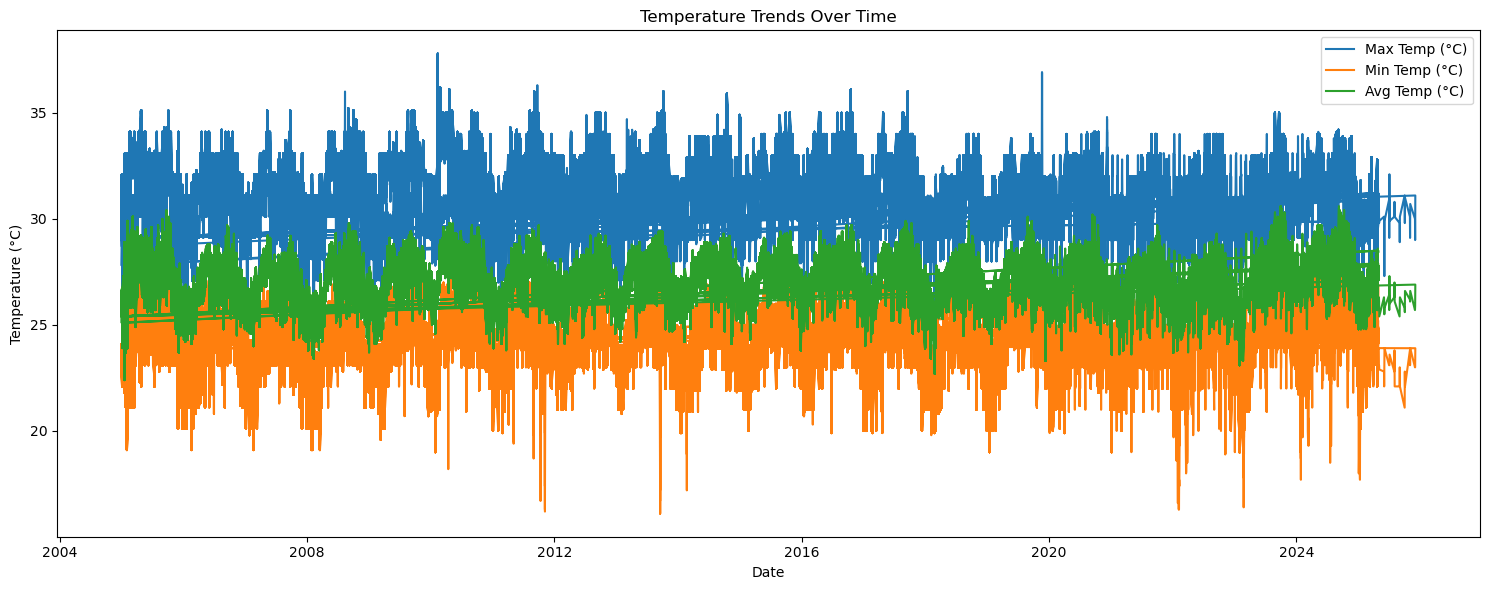

In [78]:
plt.figure(figsize=(15, 6))
plt.plot(weather.index, weather['tempmax c'], label='Max Temp (°C)')
plt.plot(weather.index, weather['tempmin c'], label='Min Temp (°C)')
plt.plot(weather.index, weather['avgtemp c'], label='Avg Temp (°C)')
plt.title('Temperature Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

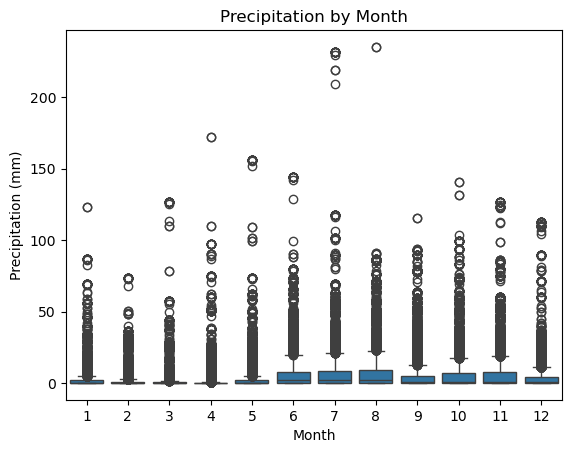

In [79]:
weather['month'] = weather.index.month

sns.boxplot(data=weather, x='month', y='precip')
plt.title('Precipitation by Month')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.show()

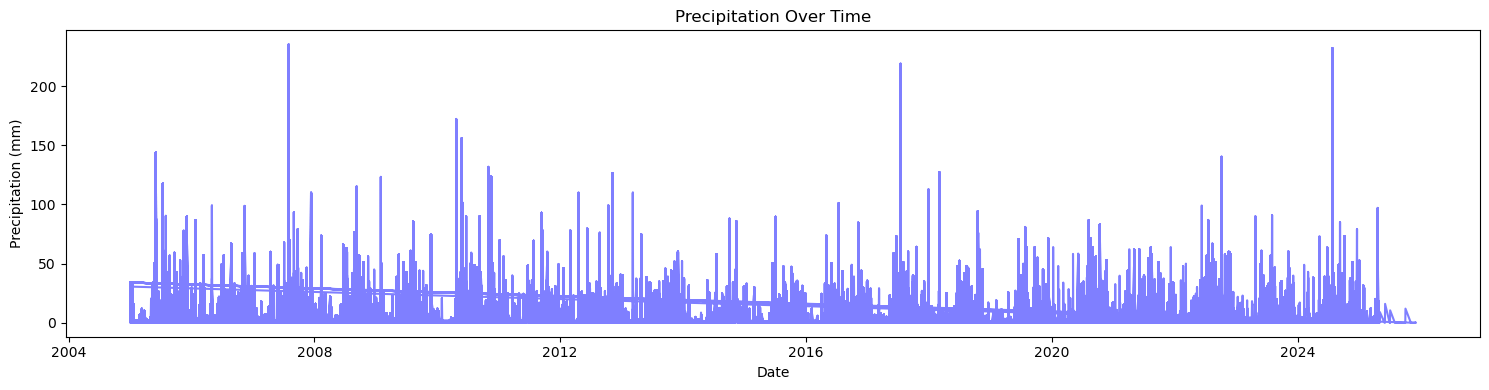

In [80]:
plt.figure(figsize=(15, 4))
plt.plot(weather.index, weather['precip'], color='blue', alpha=0.5)
plt.title('Precipitation Over Time')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.tight_layout()
plt.show()

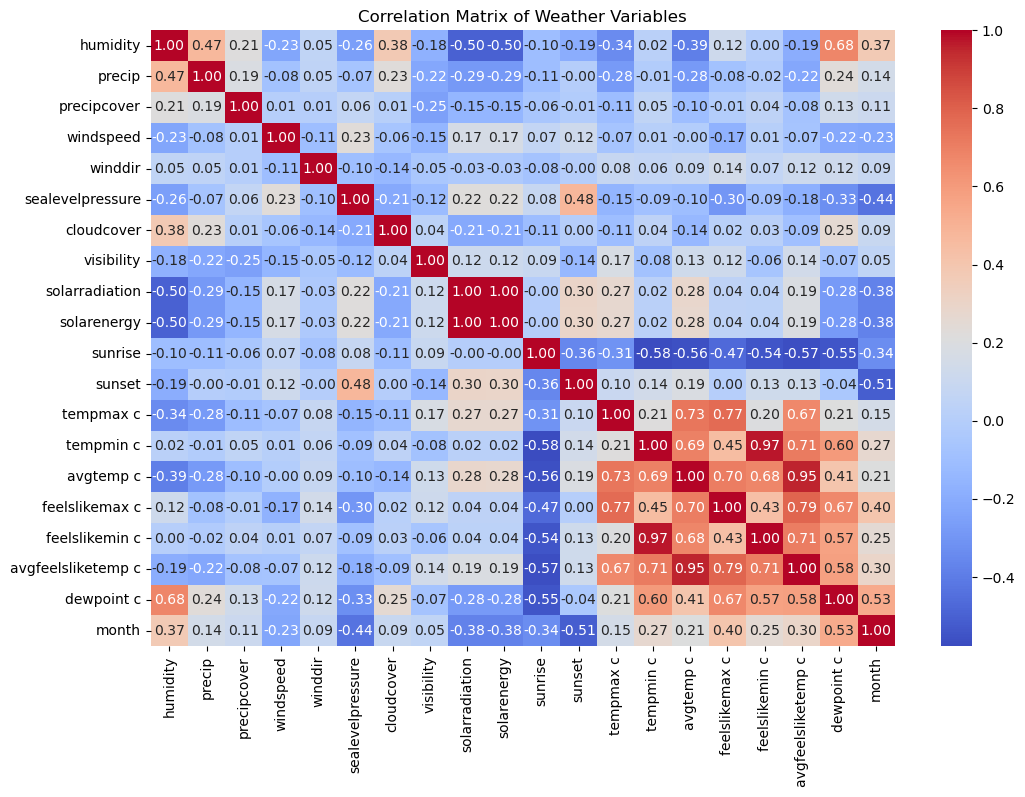

In [81]:
plt.figure(figsize=(12, 8))
sns.heatmap(weather.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Weather Variables')
plt.show()

In [82]:
import plotly.express as px
import pandas as pd

corr = weather.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title="Correlation Matrix of Weather Variables"
)
fig.update_layout(width=800, height=800)
fig.update_xaxes(title_text='Variables')
fig.update_yaxes(title_text='Variables')
fig.update_traces(hovertemplate='Variable: %{x}<br>Correlation: %{z:.2f}')
fig.update_layout(
    title={
        'text': "Correlation Matrix of Weather Variables",
        'x': 0.5,  # Center the title
        'xanchor': 'center'
    }  
)
fig.update_xaxes(title_text='Variables', tickangle=-90)

fig.show()


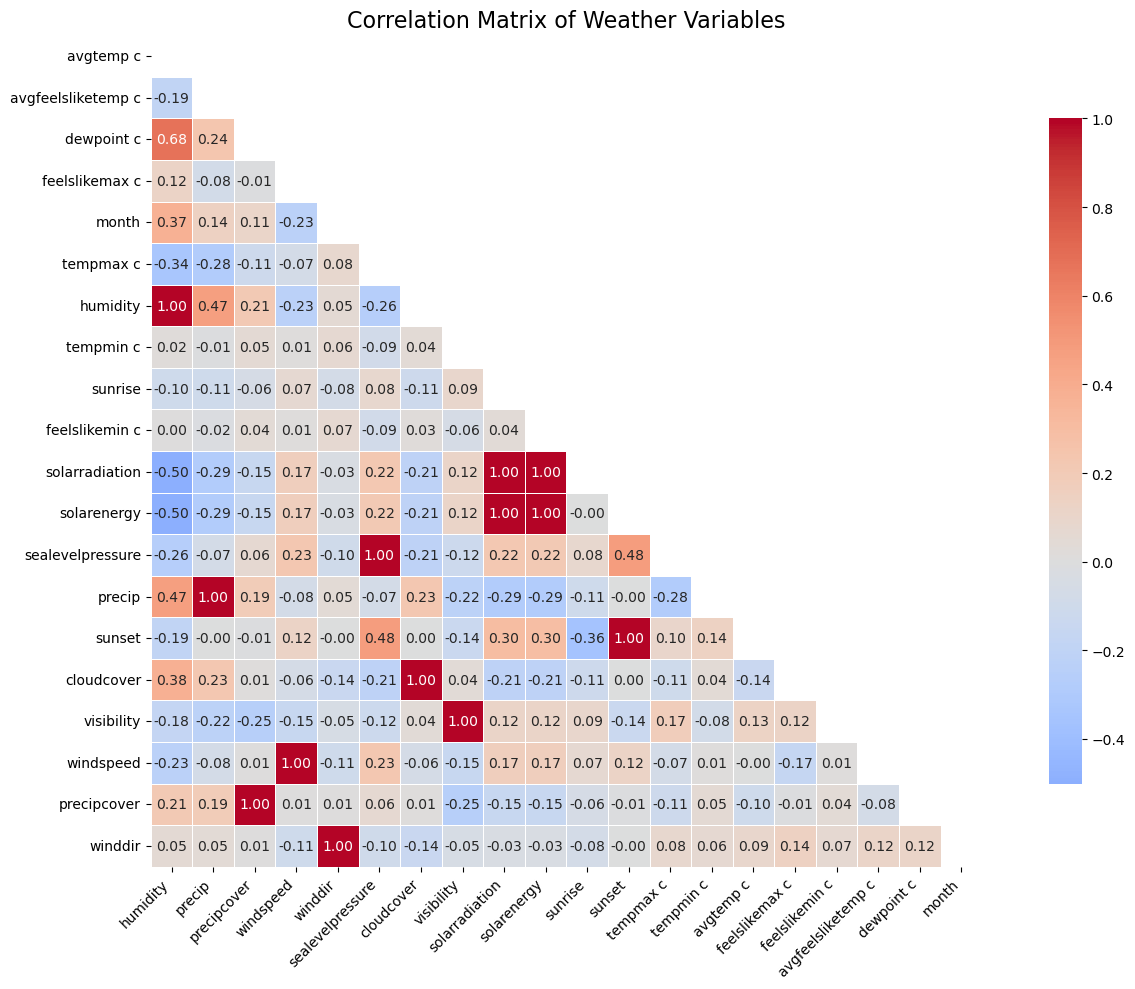

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute correlation and sort by similarity (optional)
corr = weather.corr(numeric_only=True)
corr = corr.loc[corr.abs().sum().sort_values(ascending=False).index]  # Sort rows/cols

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    mask=np.triu(np.ones_like(corr, dtype=bool))  # Optional: only show lower triangle
)
plt.title("Correlation Matrix of Weather Variables", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


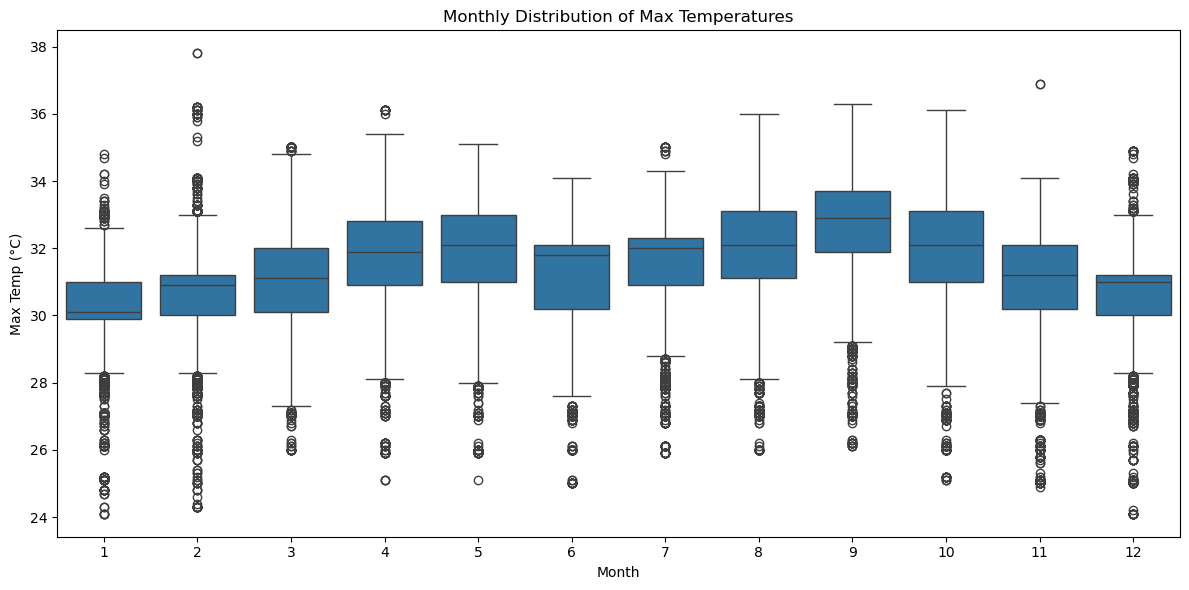

In [84]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=weather, x='month', y='tempmax c')
plt.title('Monthly Distribution of Max Temperatures')
plt.xlabel('Month')
plt.ylabel('Max Temp (°C)')
plt.tight_layout()
plt.show()

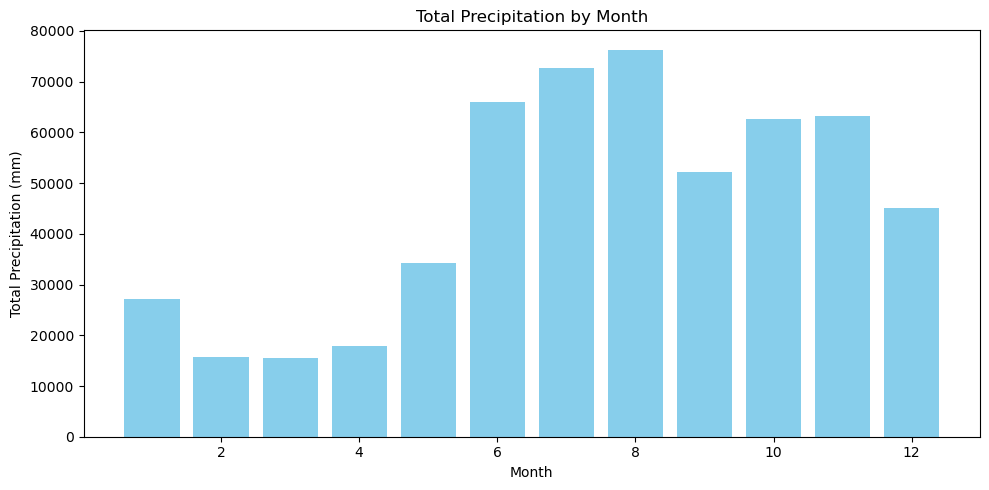

In [85]:
monthly_precip = weather.groupby('month')['precip'].sum()
plt.figure(figsize=(10, 5))
plt.bar(monthly_precip.index, monthly_precip.values, color='skyblue')
plt.title('Total Precipitation by Month')
plt.xlabel('Month')
plt.ylabel('Total Precipitation (mm)')
plt.tight_layout()
plt.show()

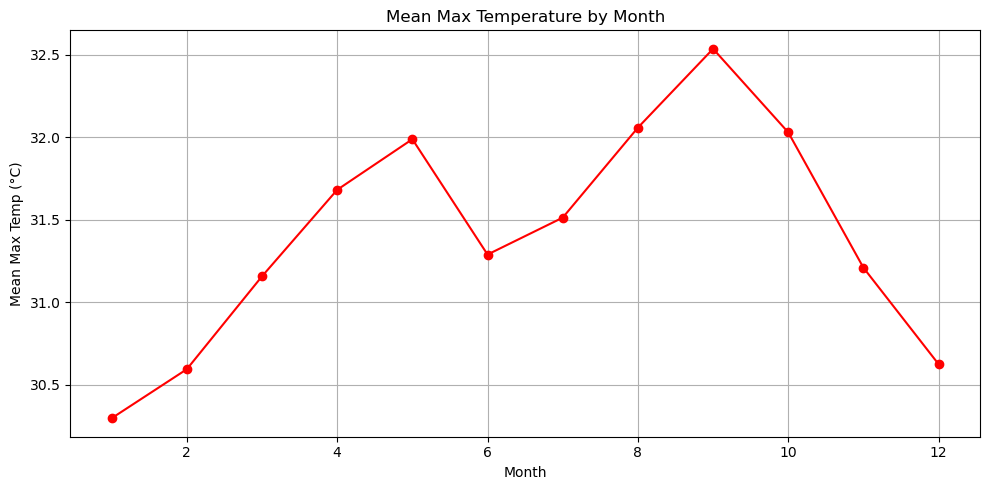

In [86]:
monthly_max = weather.groupby('month')['tempmax c'].mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_max.index, monthly_max.values, marker='o', color='red')
plt.title('Mean Max Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Mean Max Temp (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

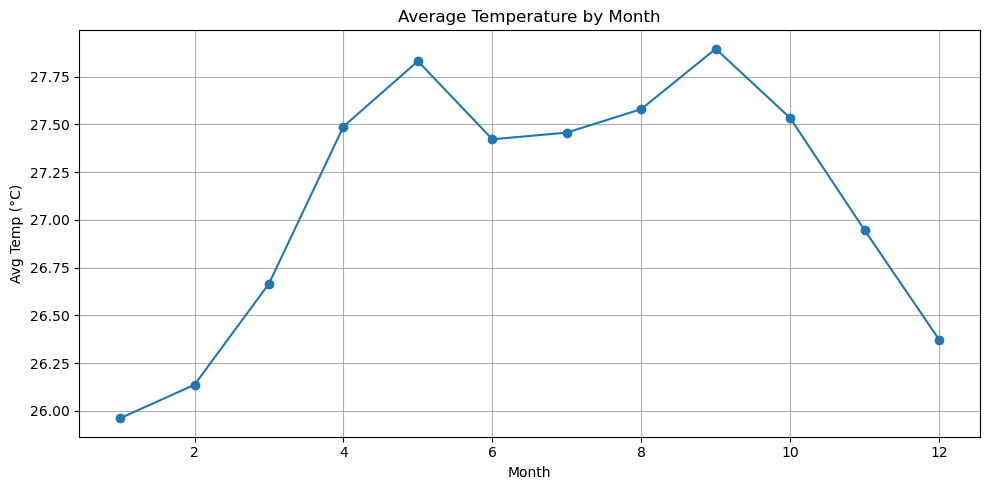

In [87]:
monthly_avg = weather.groupby('month')['avgtemp c'].mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title('Average Temperature by Month')
plt.xlabel('Month')
plt.ylabel('Avg Temp (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

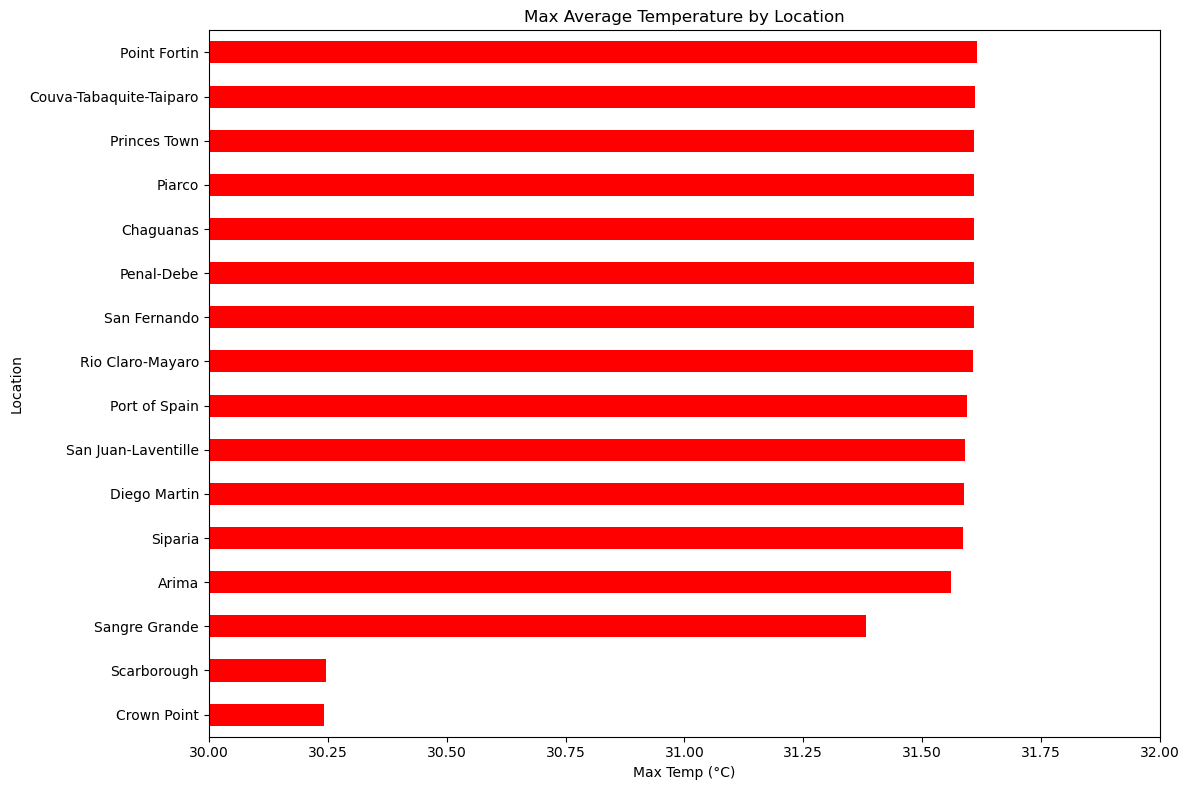

In [88]:
loc_avg = weather.groupby('name')['tempmax c'].mean().sort_values()
# Limit x-axis to a sensible temperature range for Trinidad (e.g., 22°C to 30°C)
ax = loc_avg.plot(kind='barh', figsize=(12, 8), color='red')
ax.set_xlim(30, 32)
plt.title('Max Average Temperature by Location')
plt.xlabel('Max Temp (°C)')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

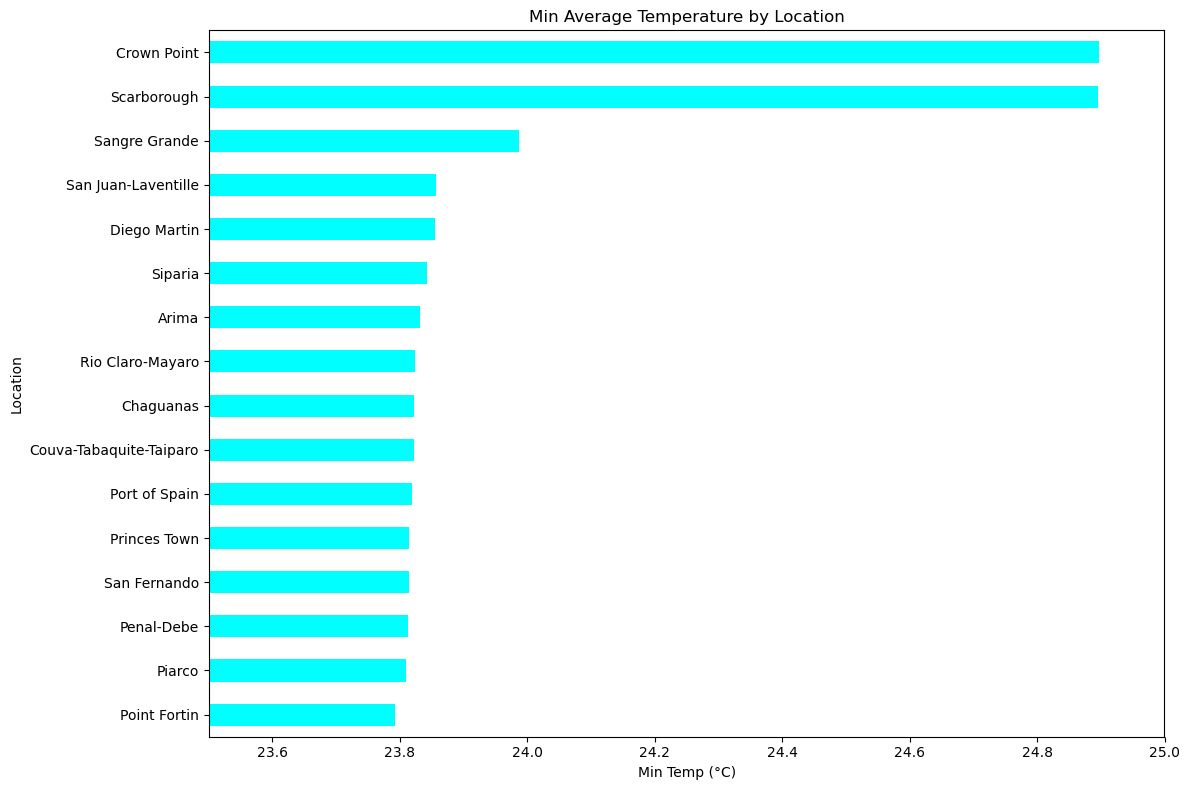

In [89]:
loc_avg = weather.groupby('name')['tempmin c'].mean().sort_values()
# Limit x-axis to a sensible temperature range for Trinidad (e.g., 22°C to 30°C)
ax = loc_avg.plot(kind='barh', figsize=(12, 8), color='cyan')
ax.set_xlim(23.5,25)
plt.title('Min Average Temperature by Location')
plt.xlabel('Min Temp (°C)')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

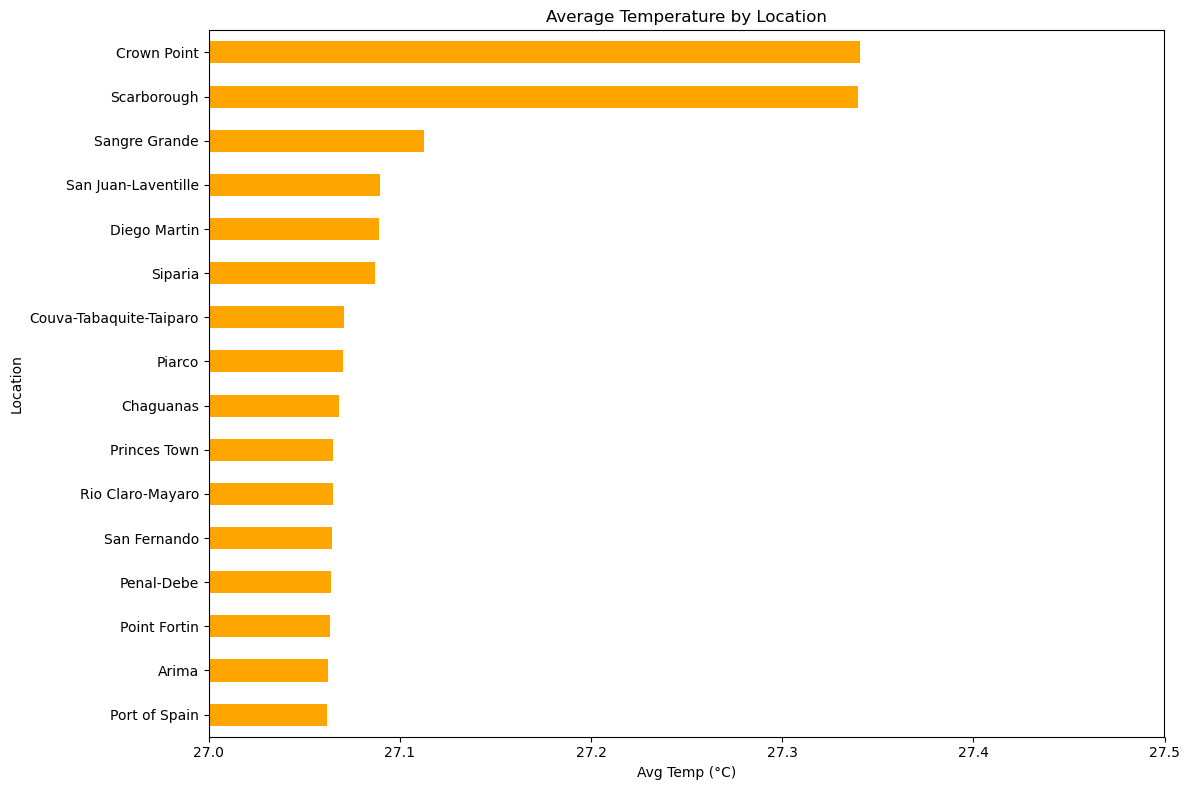

In [90]:
loc_avg = weather.groupby('name')['avgtemp c'].mean().sort_values()
# Limit x-axis to a sensible temperature range for Trinidad (e.g., 22°C to 30°C)
ax = loc_avg.plot(kind='barh', figsize=(12, 8), color='orange')
ax.set_xlim(27, 27.5)
plt.title('Average Temperature by Location')
plt.xlabel('Avg Temp (°C)')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

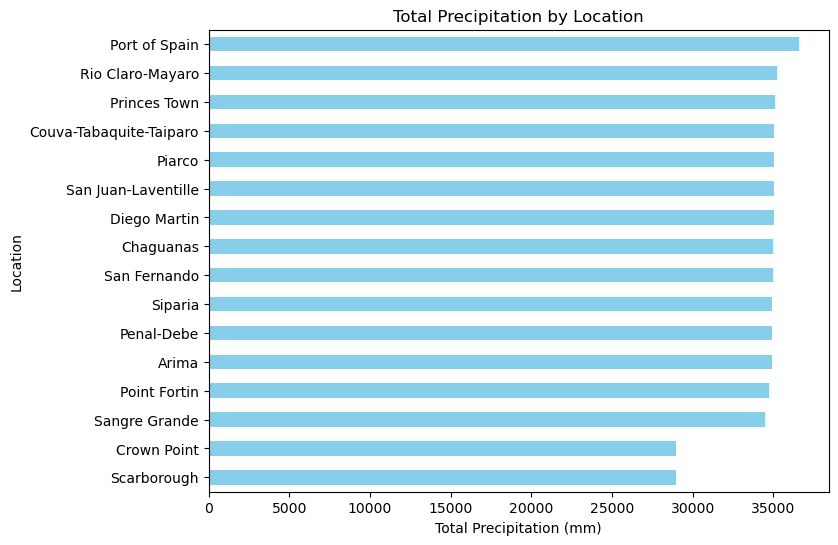

In [91]:
loc_precip = weather.groupby('name')['precip'].sum().sort_values()
loc_precip.plot(kind='barh', figsize=(8, 6), color='skyblue')
plt.title('Total Precipitation by Location')
plt.xlabel('Total Precipitation (mm)')
plt.ylabel('Location')
plt.show()

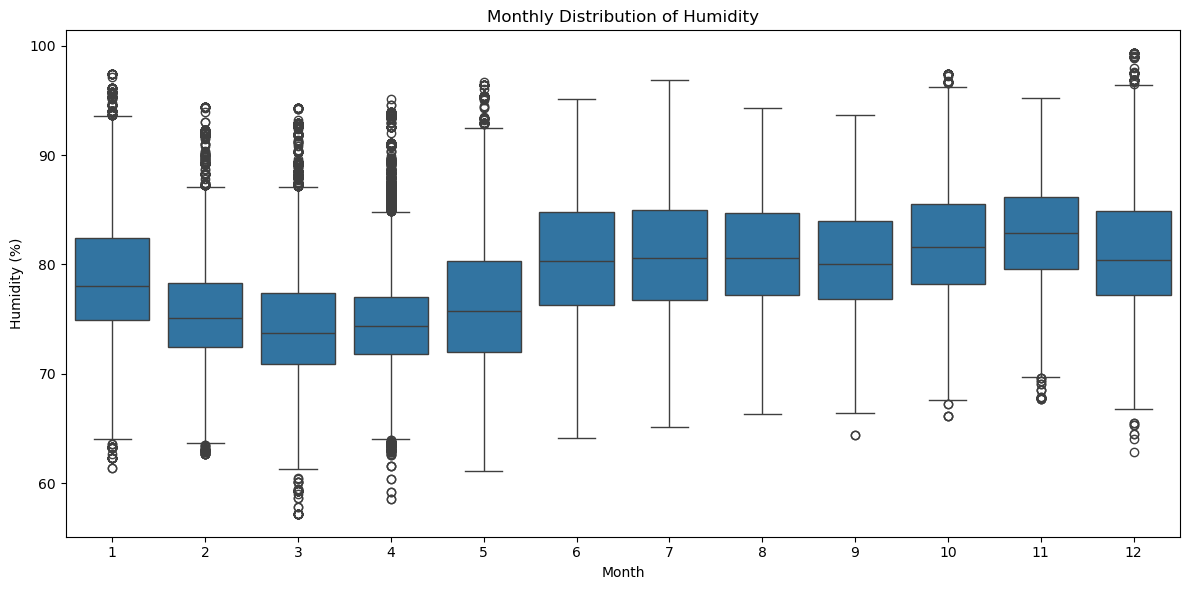

In [92]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=weather, x='month', y='humidity')
plt.title('Monthly Distribution of Humidity')
plt.xlabel('Month')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

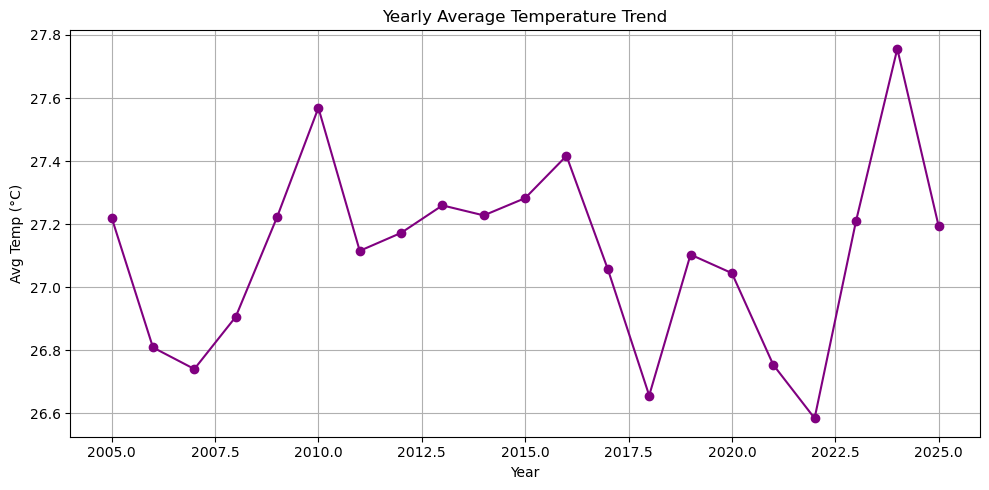

In [93]:
yearly_avg = weather.groupby(weather.index.year)['avgtemp c'].mean()
plt.figure(figsize=(10, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', color='purple')
plt.title('Yearly Average Temperature Trend')
plt.xlabel('Year')
plt.ylabel('Avg Temp (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

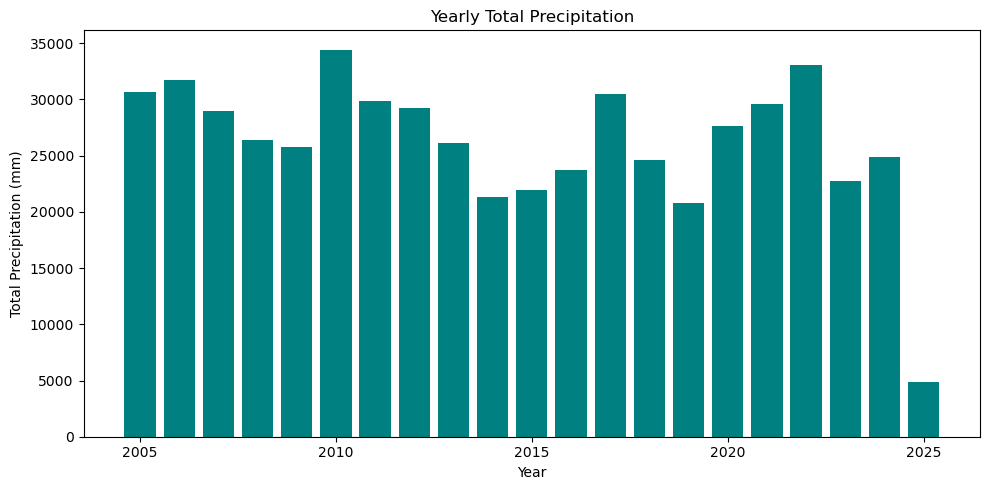

In [94]:
yearly_precip = weather.groupby(weather.index.year)['precip'].sum()
plt.figure(figsize=(10, 5))
plt.bar(yearly_precip.index, yearly_precip.values, color='teal')
plt.title('Yearly Total Precipitation')
plt.xlabel('Year')
plt.ylabel('Total Precipitation (mm)')
plt.tight_layout()
plt.show()